
## (o_hmt_rt) model for PDF shaping (n samples)

This uses the new object oriented class for PDF shaping.

* o_hmt ...... i_h2i_rate, i_h2_temp, i_ng_rate, i_ng_temp, i_pci_rate, i_wpi_rate, i_sgi_rate, i_sgi_COH2ratio, i_sgi_ReProRatio, i_o2_volfract, i_hbtemp, i_wind_rt, i_blast_H2O, i_bdn_H2O

## Web applicationi inputs and 1 outputs

Run interactively on the web at: https://rcalix1.github.io/ProbabilityDensityFunctionsFromNeuralNets/experiments/2023/july2023/XGBoost/deployment/tuyere/




## Inputs


(2, 'i_h2i_rate').........i_h2i_rate

(3, 'i_pci_rate').........i_pci_rate

(4, 'i_wpi_rate').........i_wpi_rate

(5, 'i_ngi_rate').........i_ng_rate

(6, 'i_o2_volfract').......i_o2_volfract

(7, 'i_ng_temp')...........i_ng_temp

(8, 'i_h2_temp')...........i_h2_temp

(9, 'i_hbtemp')............i_hbtemp

(10, 'i_wind_rt')..........i_wind_rt

(11, 'i_blastH2O').........i_blast_H2O

(12, 'i_BdnH2O')............i_bdn_H2O

(13, 'i_sgi_rate').........i_sgi_rate

(15, 'i_sgi_COH2ratio').....i_sgi_COH2ratio

(16, 'i_sgi_ReProRatio')....i_sgi_ReProRatio


  

## Outputs


(29, 'o_hmt')






## Installs


In [1]:

## !pip install xgboost
## !pip install onnxmltools
## !pip install onnxruntime



## Imports


In [2]:

import torch
import numpy as np
import pandas as pd
import sklearn
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import math
import seaborn as sns
import random
import functorch


import torch.optim as optim


from numpy.random import normal
from scipy.stats import norm
import scipy.stats as stats
from numpy import hstack
from numpy import vstack
from numpy import exp
from sklearn.neighbors import KernelDensity

##from typing import Optional

from torch import Tensor


from torch.utils.data import TensorDataset, DataLoader

from mlxtend.plotting import heatmap

## coefficient of determination (R**2)
from sklearn.metrics import r2_score

np.set_printoptions(suppress=True)
torch.set_printoptions(sci_mode=False)




In [3]:

import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor, DMatrix, train as train_xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import onnxmltools
from onnxmltools.convert.xgboost.operator_converters.XGBoost import (
    convert_xgboost)
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster


from zipfile import ZipFile
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx import convert_sklearn, to_onnx, update_registered_converter
from skl2onnx.common.shape_calculator import (
    calculate_linear_classifier_output_shapes,
    calculate_linear_regressor_output_shapes)


# Import the ONNX runtime environment
import onnxruntime as rt



/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/onnx_ops.py:159: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  tys = obj.typeStr or ''
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/automation.py:154: UserWarning: OpSchema.FormalParameter.isHomogeneous is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.is_homogeneous instead.
  if getattr(obj, 'isHomogeneous', False):
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/jinja2/environment.py:485: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  return getattr(obj, attribute)


In [4]:

import PDFshapingUtils as PDF_tk



## Instantiate PDF shaping and regression class


In [5]:

PDFshapingOBJ = PDF_tk.PDFshapingUtils()



## Initialize parameters


In [6]:

PDFshapingOBJ.N_error_range = 5         ## 20
PDFshapingOBJ.mean_impulse  = 0.0       ## -7.0      ## 0.0
PDFshapingOBJ.std_impulse   = 0.001     ## 1.0
PDFshapingOBJ.kde_std       = 0.5       ## 0.1       ## 0.5      ## 3.0  ## smaller is better approximation?
PDFshapingOBJ.bandwidth     = 0.2       ## 0.2->more jagged, 2.0->more smooth


In [7]:

PDFshapingOBJ.initializeImpulseGaussian()



## Run checks


In [8]:

## print(PDFshapingOBJ.x_range_impulse_func )
## print(PDFshapingOBJ.impulse_func_vector_vals )
## print(PDFshapingOBJ.quadratic_weights)
print(PDFshapingOBJ.x_range_impulse_func.shape )
print(PDFshapingOBJ.impulse_func_vector_vals.shape )
print(PDFshapingOBJ.quadratic_weights.shape)
 
print( sum(PDFshapingOBJ.impulse_func_vector_vals) )      ## should add up to 100 (i.e. 1.0 prob density)


torch.Size([1000])
torch.Size([1000])
torch.Size([1000])
tensor(100.0000)


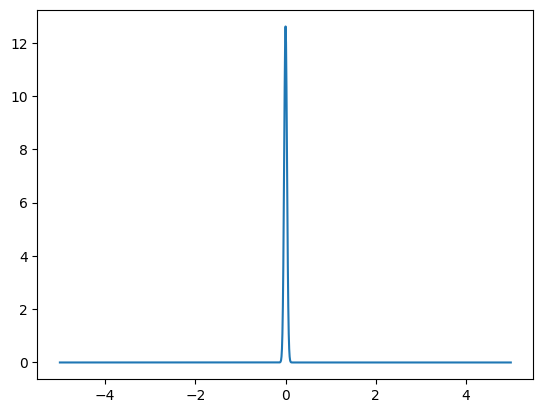

In [9]:

plt.plot(PDFshapingOBJ.x_range_impulse_func, PDFshapingOBJ.impulse_func_vector_vals)
plt.show()



## RUN KDE test


In [10]:

## PDFshapingOBJ.test_torchKDE_with_fake_data()



## Load Data


In [11]:

PDFshapingOBJ.read_csv_file_with_pandas('CFD.15.2025.csv')


In [12]:

PDFshapingOBJ.CFD_raw_data


,index,case name,i_h2i_rate,i_pci_rate,i_wpi_rate,i_ngi_rate,i_o2_volfract,i_ng_temp,i_h2_temp,i_hbtemp,...,o_h2o_sollos,o_feo_sollos,o_hm_rt,o_mw_rt,o_wf_rt,o_hm_h2share,o_mw_h2share,o_wf_h2share,o_prod_rt,o_fta
0,1,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1200,...,18.5,52.6,122.0,265.0,684.0,27.9,23.4,60.6,4060.0,1850.0
1,2,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1200,...,18.7,45.4,145.0,312.0,821.0,24.2,22.6,57.4,4790.0,1890.0
2,3,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1480,...,17.9,30.2,160.0,345.0,930.0,40.7,17.0,57.6,5290.0,1910.0
3,4,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1480,...,18.2,39.1,191.0,413.0,1140.0,25.8,19.1,53.2,6330.0,2040.0
4,5,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1600,...,19.6,29.6,166.0,360.0,977.0,40.3,16.5,58.8,5510.0,1980.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4183,4184,H2-50_PCI-0_WPI-0_NG-0_O2-30_NGT-0_H2T-600_HBT...,50,0,0,0,30,0,600,1600,...,18.3,40.2,336.0,726.0,2100.0,30.8,25.3,58.0,11100.0,2630.0
4184,4185,H2-50_PCI-0_WPI-0_NG-0_O2-30_NGT-300_H2T-0_HBT...,50,0,0,0,30,300,0,1200,...,19.4,39.9,295.0,638.0,1790.0,32.9,28.1,57.7,9790.0,2200.0
4185,4186,H2-50_PCI-0_WPI-0_NG-0_O2-30_NGT-300_H2T-0_HBT...,50,0,0,0,30,300,0,1448,...,18.1,42.0,295.0,639.0,1800.0,33.4,28.3,58.4,9780.0,2360.0
4186,4187,H2-50_PCI-0_WPI-0_NG-0_O2-30_NGT-300_H2T-0_HBT...,50,0,0,0,30,300,0,1448,...,19.6,39.6,295.0,638.0,1800.0,33.3,28.2,58.3,9790.0,2310.0


In [13]:

PDFshapingOBJ.print_headers_list()


['index', 'case name', 'i_h2i_rate', 'i_pci_rate', 'i_wpi_rate', 'i_ngi_rate', 'i_o2_volfract', 'i_ng_temp', 'i_h2_temp', 'i_hbtemp', 'i_wind_rt', 'i_blastH2O', 'i_BdnH2O', 'i_sgi_rate', 'i_sgtemp', 'i_sgi_COH2ratio', 'i_sgi_ReProRatio', 'o_tuy_velo', 'o_tuy_temp', 'o_burn', 'o_delp', 'o_co_vf', 'o_co2_vf', 'o_h2_vf', 'o_n2_vf', 'o_co_util', 'o_h2_util', 'o_tgt', 'o_coke_rt', 'o_hmt', 'o_co2_sollos', 'o_h2o_sollos', 'o_feo_sollos', 'o_hm_rt', 'o_mw_rt', 'o_wf_rt', 'o_hm_h2share', 'o_mw_h2share', 'o_wf_h2share', 'o_prod_rt', 'o_fta']
41
(0, 'index')
(1, 'case name')
(2, 'i_h2i_rate')
(3, 'i_pci_rate')
(4, 'i_wpi_rate')
(5, 'i_ngi_rate')
(6, 'i_o2_volfract')
(7, 'i_ng_temp')
(8, 'i_h2_temp')
(9, 'i_hbtemp')
(10, 'i_wind_rt')
(11, 'i_blastH2O')
(12, 'i_BdnH2O')
(13, 'i_sgi_rate')
(14, 'i_sgtemp')
(15, 'i_sgi_COH2ratio')
(16, 'i_sgi_ReProRatio')
(17, 'o_tuy_velo')
(18, 'o_tuy_temp')
(19, 'o_burn')
(20, 'o_delp')
(21, 'o_co_vf')
(22, 'o_co2_vf')
(23, 'o_h2_vf')
(24, 'o_n2_vf')
(25, 'o_co_ut

/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/numpy/lib/function_base.py:2691: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[:, None]
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/numpy/lib/function_base.py:2692: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[None, :]


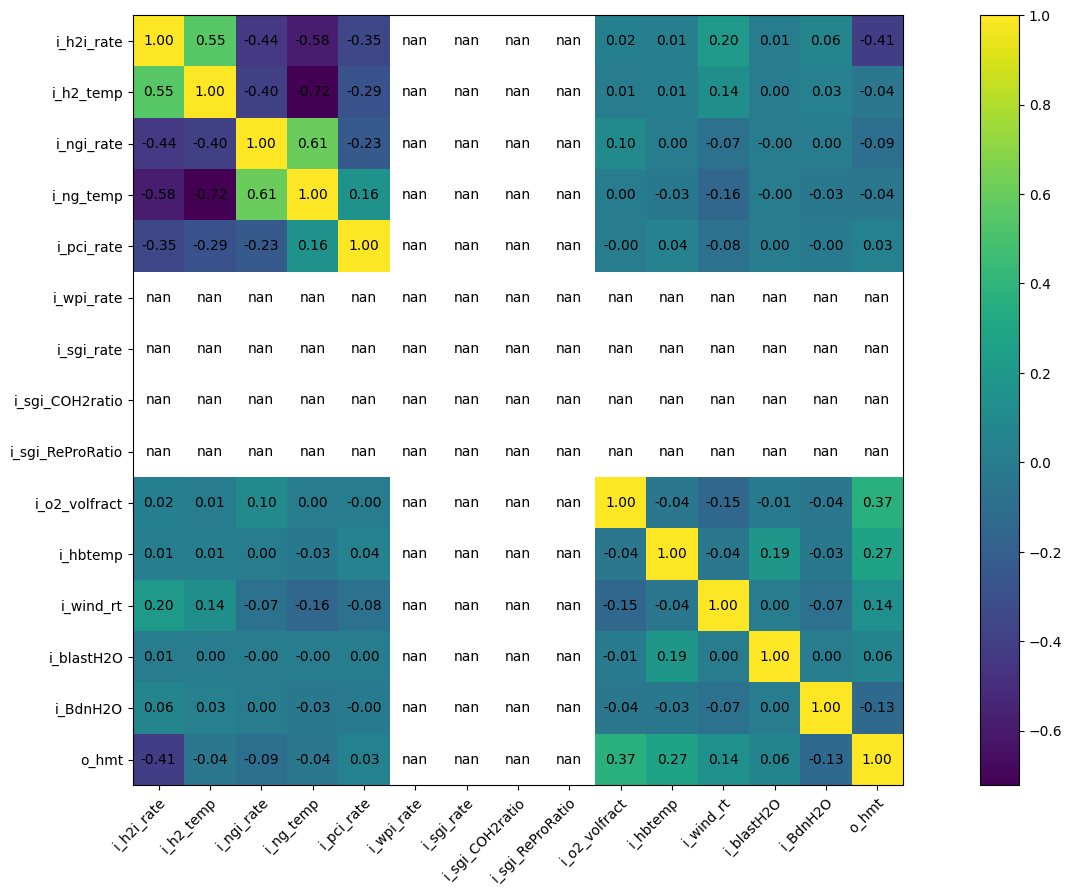

In [14]:

PDFshapingOBJ.list_of_selected_column_names = ['i_h2i_rate','i_h2_temp','i_ngi_rate','i_ng_temp','i_pci_rate',
                    'i_wpi_rate','i_sgi_rate','i_sgi_COH2ratio','i_sgi_ReProRatio','i_o2_volfract',
                    'i_hbtemp','i_wind_rt','i_blastH2O','i_BdnH2O','o_hmt']



PDFshapingOBJ.print_correlation_coefficients()


In [15]:

PDFshapingOBJ.convert_pd_data_to_numpy()


[[1
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-1_SGI-0_SGT-0_SGC-0'
  0 ... 60.6 4060.0 1850.0]
 [2
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-230_MHB-5.7_BM-1_SGI-0_SGT-0_SGC-0'
  0 ... 57.4 4790.0 1890.0]
 [3
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1480_WR-160_MHB-5.7_BM-1_SGI-0_SGT-0_SGC-0'
  0 ... 57.6 5290.0 1910.0]
 ...
 [4186
  'H2-50_PCI-0_WPI-0_NG-0_O2-30_NGT-300_H2T-0_HBT-1448_WR-195_MHB-0_BM-7_SGI-0_SGT-0_SGC-0'
  50 ... 58.4 9780.0 2360.0]
 [4187
  'H2-50_PCI-0_WPI-0_NG-0_O2-30_NGT-300_H2T-0_HBT-1448_WR-195_MHB-11.4_BM-7_SGI-0_SGT-0_SGC-0'
  50 ... 58.3 9790.0 2310.0]
 [4188
  'H2-50_PCI-0_WPI-0_NG-0_O2-30_NGT-300_H2T-0_HBT-1600_WR-195_MHB-11.4_BM-7_SGI-0_SGT-0_SGC-0'
  50 ... 57.9 9780.0 2400.0]]
(4188, 41)



## Select inputs and outputs


In [16]:

PDFshapingOBJ.gen_X_y_for_selected_indeces(  
                   inputs = [ 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16 ] , 
                   outputs= [ 29 ]   
)







14
1


In [17]:

print(PDFshapingOBJ.X.shape)
print(PDFshapingOBJ.y.shape)


(4188, 14)
(4188, 1)


In [18]:

PDFshapingOBJ.random_seed = int( random.random() * 100  )         ## defautl is 42


In [19]:

PDFshapingOBJ.split_np_data_train_test(selected_test_size=0.2)


(3350, 14)
(838, 14)
(3350, 1)
(838, 1)


In [20]:

PDFshapingOBJ.convert_dataset_from_np_to_torch()


In [21]:

PDFshapingOBJ.standardize_X_scales()
PDFshapingOBJ.standardize_y_scales()


In [22]:

PDFshapingOBJ.gen_Dataloader_train()

PDFshapingOBJ.train_dl



## NN architectures


In [23]:

#######################################################
## Linear Regression

class LinRegNet_SIO(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        self.linear1 = nn.Linear(14, 1) 
        
        ## nn.init.xavier_uniform_(self.linear1.weight)
        ## nn.init.zeros_(self.linear1.bias)

    ## perform inference
    def forward(self, x):
        x = (x - self.x_means) / self.x_deviations
        
        y_scaled = self.linear1(x)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled

    
#############################################################
## Multi-Layer Perceptron

class MLP_Net_SIO(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        self.linear1 = nn.Linear(14, 10)
        self.act1    = nn.Sigmoid()                       ## Tanh() 
        self.linear2 = nn.Linear(10, 1)
        self.dropout = nn.Dropout(0.25)
        
        ## nn.init.xavier_uniform_(self.linear1.weight)
        ## nn.init.zeros_(self.linear1.bias)
        
        ## nn.init.xavier_uniform_(self.linear2.weight)
        ## nn.init.zeros_(self.linear2.bias)
    
    ## perform inference
    def forward(self, x):
        x = (x - self.x_means) / self.x_deviations
        x = self.linear1(x)
        x = self.act1(x)
        x = self.dropout(x)
        
        y_scaled = self.linear2(x)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    

#############################################################
## Deep Learning model with 2 hidden layers


class DL_Net_SIO(nn.Module):
    
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        self.linear1 = nn.Linear(14, 10)
        self.act1    = nn.Sigmoid()                       ## Tanh() 
        self.linear2 = nn.Linear(10, 6)
        self.act2    = nn.Sigmoid() 
        self.linear3 = nn.Linear(6, 1)
        self.dropout = nn.Dropout(0.25)
        
        ## nn.init.xavier_uniform_(self.linear1.weight)
        ## nn.init.zeros_(self.linear1.bias)
        
        ## nn.init.xavier_uniform_(self.linear2.weight)
        ## nn.init.zeros_(self.linear2.bias)
        
        ## nn.init.xavier_uniform_(self.linear3.weight)
        ## nn.init.zeros_(self.linear3.bias)
    
    ## perform inference
    def forward(self, x):
        
        x = (x - self.x_means) / self.x_deviations
        x = self.linear1(x)
        x = self.act1(x)
        x = self.dropout(x)
        x = self.linear2(x)
        x = self.act2(x)
        x = self.dropout(x)
        
        y_scaled = self.linear3(x)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled


In [24]:

#############################################################
##   F1      plus       F2
## Linear     +      Nonlinear

class F1plusF2_SIO(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        ## F1
        self.f1_linear1 = nn.Linear(14, 1)       
        
        ## F2
        self.f2_linear1 = nn.Linear(14, 10)
        self.f2_act1    = nn.Sigmoid()                    ## Tanh()                       
        self.f2_linear2 = nn.Linear(10, 1)       
        self.f2_dropout = nn.Dropout(0.25)
        
        
    ## perform inference
    def forward(self, x):
        x = (x - self.x_means) / self.x_deviations
        
        ## F1
        f1 = self.f1_linear1(x)
        
        ## F2
        f2 = self.f2_linear1(x)
        f2 = self.f2_act1(f2)
        f2 = self.f2_dropout(f2)
        f2 = self.f2_linear2(f2)
        
        
        y_scaled   = f1 + f2
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    



## Results for g(x) = F1(x) + F2(x) with No PDF shaping

F1 = Linear

F2 = Nonlinear


In [25]:

def fit_y_scaled(num_epochs, model, loss_fn, opt):
    
    PDFshapingOBJ.list_metric = []
    for epoch in range(num_epochs):
        for xb, yb in PDFshapingOBJ.train_dl:
            pred_descaled, pred_scaled = model(xb)
            loss = loss_fn(pred_scaled, yb)
            loss.backward()
            opt.step()
            opt.zero_grad()
        
        if epoch % 200 == 0:
            print(epoch, " loss= ", loss)
            
            
        pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
        r2_avg = torch.mean(
            torch.tensor(
                r2_score( pred_scaled.detach().numpy(),  PDFshapingOBJ.y_train_tr_scaled.numpy()   )
            )
        )
        PDFshapingOBJ.list_metric.append(  r2_avg.detach().numpy()  )
            
    PDFshapingOBJ.func_plot_performance()
            
    pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
    print('Training loss:', loss_fn(  pred_scaled,           PDFshapingOBJ.y_train_tr_scaled          ))
    print('Training R**2:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_train_tr_scaled.numpy()  ))
    


In [26]:

PDFshapingOBJ.the_string           = "No_PDF_shaping"
PDFshapingOBJ.furnace_model_name   = "o_prod_rt"


0  loss=  tensor(0.0561, grad_fn=<MseLossBackward0>)
200  loss=  tensor(0.1924, grad_fn=<MseLossBackward0>)
400  loss=  tensor(0.0368, grad_fn=<MseLossBackward0>)
600  loss=  tensor(0.2166, grad_fn=<MseLossBackward0>)
800  loss=  tensor(0.2648, grad_fn=<MseLossBackward0>)
1000  loss=  tensor(0.0469, grad_fn=<MseLossBackward0>)
1200  loss=  tensor(0.1540, grad_fn=<MseLossBackward0>)
1400  loss=  tensor(0.0393, grad_fn=<MseLossBackward0>)
1600  loss=  tensor(0.0347, grad_fn=<MseLossBackward0>)
1800  loss=  tensor(0.0428, grad_fn=<MseLossBackward0>)


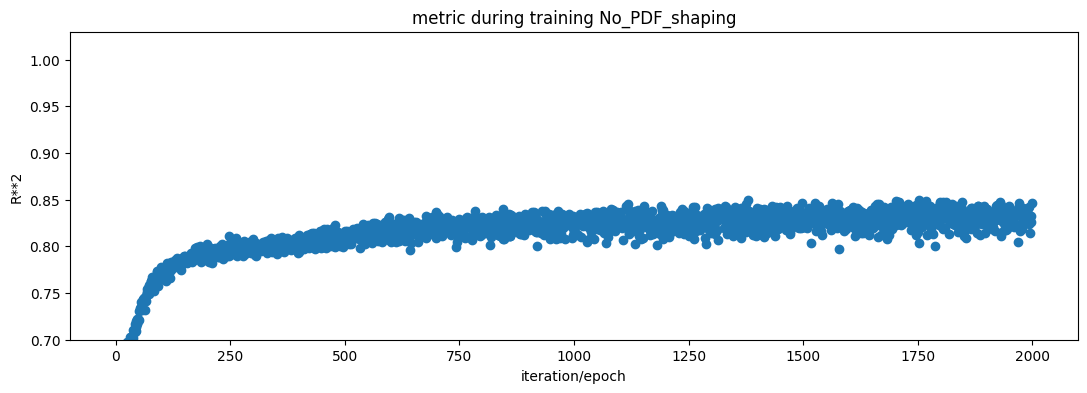

Training loss: tensor(0.1558, grad_fn=<MseLossBackward0>)
Training R**2: 0.8183466966323558
Test loss - scaled: tensor(0.1377, grad_fn=<MseLossBackward0>)
Test loss - descaled: tensor(40256.6094, grad_fn=<MseLossBackward0>)
Testing R**2 - scaled: 0.8331665878086967
Testing R**2 - descaled: 0.8331665748692101
*****
*****
Testing R**2 - Output: 0 o_hmt 0.8331665748692101


In [27]:

model = F1plusF2_SIO(
             PDFshapingOBJ.x_means, 
             PDFshapingOBJ.x_deviations, 
             PDFshapingOBJ.y_means, 
             PDFshapingOBJ.y_deviations
)

opt = torch.optim.Adam(   model.parameters(), lr=PDFshapingOBJ.learning_rate   )
loss_fn = F.mse_loss


fit_y_scaled(PDFshapingOBJ.N_EPOCHS, model, loss_fn, opt)


pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)
print('Test loss - scaled:',   loss_fn(     pred_scaled,         PDFshapingOBJ.y_test_tr_scaled          ))
print('Test loss - descaled:', loss_fn(     pred_descaled,       PDFshapingOBJ.y_test_tr                 ))
print('Testing R**2 - scaled:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()    ))

PDFshapingOBJ.print_individual_Rsquare(pred_descaled, PDFshapingOBJ.y_test_tr)


In [28]:

list_preds = []
list_reals = []

for i in range(len(PDFshapingOBJ.X_test_tr)):
    print("**************************************************")
    print("preds, real")
    preds_descaled, preds_scaled = model(PDFshapingOBJ.X_test_tr[i])

    np_pred = preds_descaled[0].detach().numpy()              ## [0]
    np_real = PDFshapingOBJ.y_test_tr[i].detach().numpy()

    for j in range(len(np_pred)):
        print((np_pred[j], np_real[j]))
        list_preds.append(np_pred[j])
        list_reals.append(np_real[j])


**************************************************
preds, real
(1094.7644, 1610.0)
**************************************************
preds, real
(1206.6163, 1140.0)
**************************************************
preds, real
(1327.1941, 1150.0)
**************************************************
preds, real
(1331.2476, 1190.0)
**************************************************
preds, real
(1133.2384, 1070.0)
**************************************************
preds, real
(1015.6077, 1030.0)
**************************************************
preds, real
(2183.1477, 2240.0)
**************************************************
preds, real
(1256.4722, 1020.0)
**************************************************
preds, real
(1372.4723, 1530.0)
**************************************************
preds, real
(953.1918, 981.0)
**************************************************
preds, real
(2108.9927, 2290.0)
**************************************************
preds, real
(717.3628, 722.0)
********

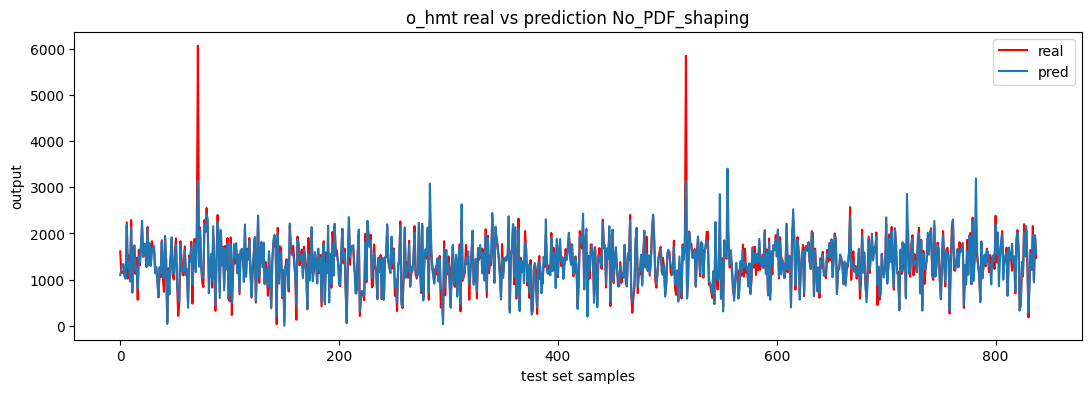

/Users/user/Desktop/CIVS_last_Phase/Forward/2025july/NewDataset/PDFshapingUtils.py:353: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error, bins=n_bins, color="blue")


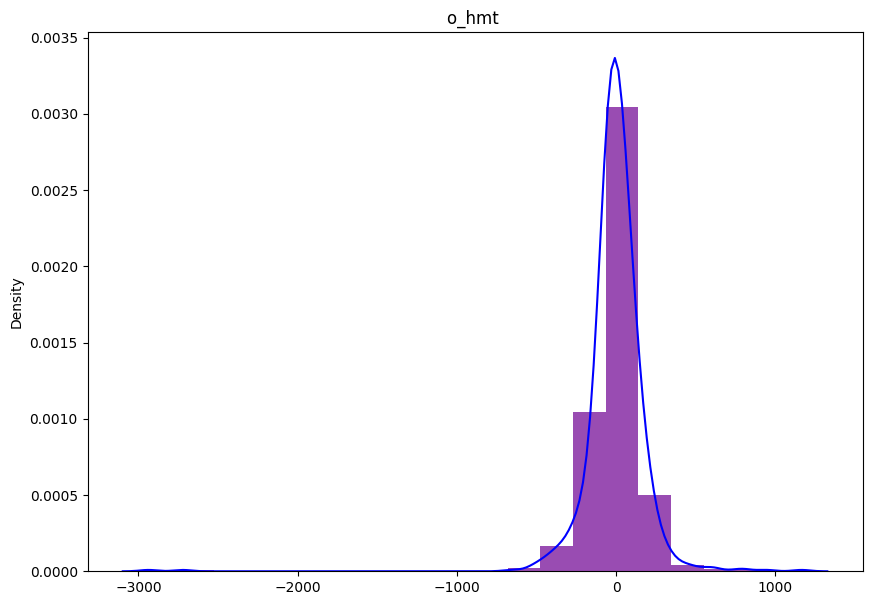

In [29]:

PDFshapingOBJ.plot_preds_vs_reals( list_preds, list_reals )



## Export ONNX model


In [30]:


model.eval()

dummy_input = torch.randn(1, 14)


input_names = ["input1"]
output_names = ["output1", "output2"]

torch.onnx.export(
  model, 
  dummy_input, 
  "ONNXmodels/F1plusF2NNs_o_prod_rt.onnx", 
  verbose=False, 
  input_names  = input_names,
  output_names = output_names
)




## To compare NNs to XGBoost


In [31]:

##      y_pred = regressor.predict(PDFshapingOBJ.X_test )

pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)


In [32]:

pred_descaled


tensor([[1112.5237],
        [1260.8021],
        [1202.9634],
        [1350.0914],
        [1167.5974],
        [1073.4309],
        [2399.5977],
        [1236.9357],
        [1554.9280],
        [ 972.0645],
        [2128.3142],
        [ 751.0950],
        [1652.7021],
        [1926.5496],
        [1134.5577],
        [1284.5942],
        [ 714.5833],
        [1835.6768],
        [1332.3263],
        [1690.4138],
        [2192.4844],
        [1554.8378],
        [1554.9072],
        [1617.9583],
        [1273.3951],
        [2048.8433],
        [1408.1833],
        [1810.0452],
        [1313.3527],
        [1722.6086],
        [1626.3677],
        [1732.0579],
        [1155.4780],
        [1308.7435],
        [ 952.3756],
        [ 661.5250],
        [1299.5880],
        [1080.0549],
        [1854.4689],
        [1062.9877],
        [ 917.5248],
        [1900.5986],
        [1413.5699],
        [ 125.5156],
        [1236.1982],
        [ 687.0126],
        [1546.8223],
        [1870

In [33]:

## r2_score( PDFshapingOBJ.y_test, y_pred )

print('Testing R**2 - scaled:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()    ))


Testing R**2 - scaled: 0.8410981461274122
Testing R**2 - descaled: 0.8410981330824202



## Results for g(x) = F1(x) + F2(x) with PDF shaping

F1 = Linear

F2 = Nonlinear


In [34]:

def fit_y_scaled_PDF(num_epochs, num_epochs_pdf, model, loss_fn, opt, kl_loss, scheduler):
    
    PDFshapingOBJ.list_metric = []
      
    for epoch in range(num_epochs):
        for xb, yb in PDFshapingOBJ.train_dl:
            
            pred_descaled, pred_scaled = model(xb)
            loss = loss_fn(pred_scaled, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            
            
        if epoch % 200 == 0:
            print(epoch, " loss= ", loss)
        
        pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
        r2_avg = torch.mean(torch.tensor(
                r2_score( pred_scaled.detach().numpy(),  PDFshapingOBJ.y_train_tr_scaled.numpy()  )
        ))
        PDFshapingOBJ.list_metric.append(r2_avg.detach().numpy())
        
        
    opt = torch.optim.Adam(   model.parameters(), lr=PDFshapingOBJ.learning_rate_pdfcontrol  )    
        
    for epoch in range(num_epochs_pdf):
        
        pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
       
        error =   pred_scaled.float() - PDFshapingOBJ.y_train_tr_scaled.float()          ## 715  x 1
        
        basisFunc = PDFshapingOBJ.train_multiple_kernels_per_output( error )             ## 1000 x 1
        
        p_pred = basisFunc.float() 
        q_real = PDFshapingOBJ.impulse_func_vector_vals.unsqueeze(1).float() 
        
        
        diff = ( p_pred - q_real )**2              ## 1000 x 1
        diff = diff * PDFshapingOBJ.quadratic_weights.unsqueeze(1)      
          
        
        loss = torch.mean( diff  ) 
        

        ## loss_diff = loss_fn(p_pred, q_real)
        ## input_kl  = F.log_softmax(p_pred, dim=0) # F.log_softmax(p_kl)
        ## target_kl = F.softmax(    q_real, dim=0) # F.softmax(q_kl)
        ## loss =  loss_diff   ## kl_loss(input_kl, target_kl)  ##   +  torch.std(p_pred)
        
        
        opt.zero_grad()
        loss.backward()
        opt.step()
        
      
        
        ## PDFshapingOBJ.updateImpulseGaussian_with_new_standard_deviation(decay_impulse_std )
        

        ## print(epoch, " loss= ", loss)
        if epoch % 5000 == 0:
            print(epoch, " loss= ", loss)
            print(PDFshapingOBJ.impulse_func_vector_vals.shape )
            print(PDFshapingOBJ.quadratic_weights.shape)
            print(error.shape)
            print(basisFunc.shape)
            ##### PDFshapingOBJ.print_errors_kdes(  error, basisFunc )
            print(PDFshapingOBJ.impulse_func_vector_vals.shape)
            print('Epoch-{0} lr: {1}'.format(epoch, opt.param_groups[0]['lr']))
      

        r2_avg = torch.mean(torch.tensor(
                 r2_score( pred_scaled.detach().numpy(),  PDFshapingOBJ.y_train_tr_scaled.numpy()  )
        ))
        PDFshapingOBJ.list_metric.append(  r2_avg.detach().numpy()  )
        
        
            
    PDFshapingOBJ.func_plot_performance()
            
    pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
    print('Training loss:', loss_fn(  pred_scaled,       PDFshapingOBJ.y_train_tr_scaled          ))
    print('Training R**2:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_train_tr_scaled.numpy() ))
    


In [35]:

PDFshapingOBJ.the_string           = "With_PDF_shaping"
PDFshapingOBJ.furnace_model_name   = "o_prod_rt"

PDFshapingOBJ.learning_rate_pdfcontrol  = 0.001       ## 0.001
PDFshapingOBJ.N_EPOCHS_PDF              = 30000
PDFshapingOBJ.N_EPOCHS                  = 0

decay_impulse_std                       = PDFshapingOBJ.std_impulse / PDFshapingOBJ.N_EPOCHS_PDF 


10000
0  loss=  tensor(0.0147, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3350, 1])
torch.Size([1000, 1])
torch.Size([1000])
Epoch-0 lr: 0.001
5000  loss=  tensor(0.0023, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3350, 1])
torch.Size([1000, 1])
torch.Size([1000])
Epoch-5000 lr: 0.001
10000  loss=  tensor(0.0021, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3350, 1])
torch.Size([1000, 1])
torch.Size([1000])
Epoch-10000 lr: 0.001
15000  loss=  tensor(0.0020, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3350, 1])
torch.Size([1000, 1])
torch.Size([1000])
Epoch-15000 lr: 0.001
20000  loss=  tensor(0.0020, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3350, 1])
torch.Size([1000, 1])
torch.Size([1000])
Epoch-20000 lr: 0.001
25000  loss=  tensor(0.0020, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3350, 1])
torch

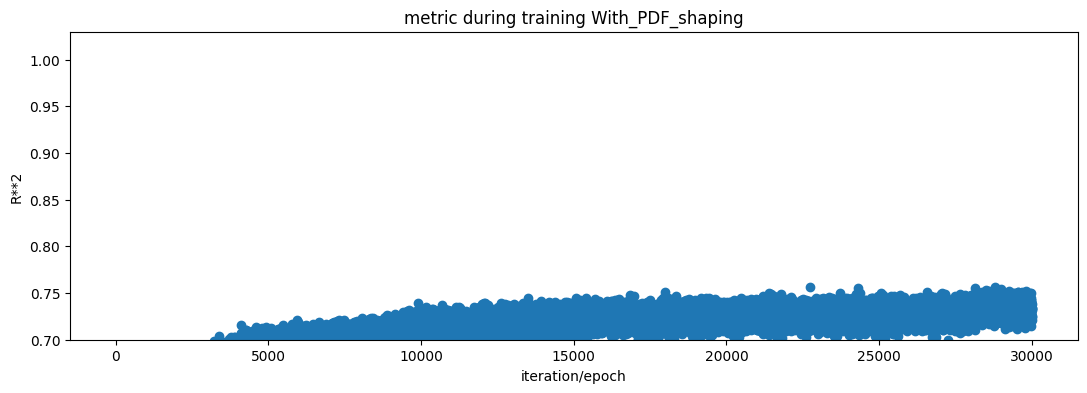

Training loss: tensor(0.2351, grad_fn=<MseLossBackward0>)
Training R**2: 0.72866574833071
Test loss - scaled: tensor(0.2316, grad_fn=<MseLossBackward0>)
Test loss - descaled: tensor(67704.7812, grad_fn=<MseLossBackward0>)
Testing R**2 - scaled: 0.7167439632666006
Testing R**2 - descaled: 0.7167439515908824
*****
*****
Testing R**2 - Output: 0 o_hmt 0.7167439515908824


In [36]:

model = F1plusF2_SIO(
             PDFshapingOBJ.x_means, 
             PDFshapingOBJ.x_deviations, 
             PDFshapingOBJ.y_means, 
             PDFshapingOBJ.y_deviations
)



opt         = torch.optim.Adam(   model.parameters(), lr=PDFshapingOBJ.learning_rate_pdfcontrol    )


step_size_scheduler = int(PDFshapingOBJ.N_EPOCHS_PDF / 3)
print(step_size_scheduler)
                          
scheduler   = torch.optim.lr_scheduler.StepLR(opt, step_size=1000, gamma=0.1)



loss_fn      = F.mse_loss
kl_loss      = nn.KLDivLoss(reduction="batchmean")
loss_softmax = F.binary_cross_entropy


fit_y_scaled_PDF(PDFshapingOBJ.N_EPOCHS, PDFshapingOBJ.N_EPOCHS_PDF, model, loss_fn, opt, kl_loss, scheduler)

pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)
print('Test loss - scaled:',   loss_fn(     pred_scaled,       PDFshapingOBJ.y_test_tr_scaled          ))
print('Test loss - descaled:', loss_fn(     pred_descaled,     PDFshapingOBJ.y_test_tr                 ))
print('Testing R**2 - scaled:',   r2_score( pred_scaled.detach().numpy(),PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()   ))


PDFshapingOBJ.print_individual_Rsquare(pred_descaled, PDFshapingOBJ.y_test_tr)


In [37]:

list_preds = []
list_reals = []

for i in range(len(PDFshapingOBJ.X_test_tr)):
    print("**************************************************")
    print("preds, real")
    preds_descaled, preds_scaled = model(PDFshapingOBJ.X_test_tr[i])

    np_pred = preds_descaled[0].detach().numpy()              ## [0]
    np_real = PDFshapingOBJ.y_test_tr[i].detach().numpy()

    for j in range(len(np_pred)):
        print((np_pred[j], np_real[j]))
        list_preds.append(np_pred[j])
        list_reals.append(np_real[j])


**************************************************
preds, real
(1066.9819, 1610.0)
**************************************************
preds, real
(1292.4092, 1140.0)
**************************************************
preds, real
(1159.305, 1150.0)
**************************************************
preds, real
(1244.7, 1190.0)
**************************************************
preds, real
(1105.2935, 1070.0)
**************************************************
preds, real
(1060.4744, 1030.0)
**************************************************
preds, real
(2399.0225, 2240.0)
**************************************************
preds, real
(1071.1624, 1020.0)
**************************************************
preds, real
(1696.9946, 1530.0)
**************************************************
preds, real
(981.6151, 981.0)
**************************************************
preds, real
(2254.981, 2290.0)
**************************************************
preds, real
(716.6839, 722.0)
*************

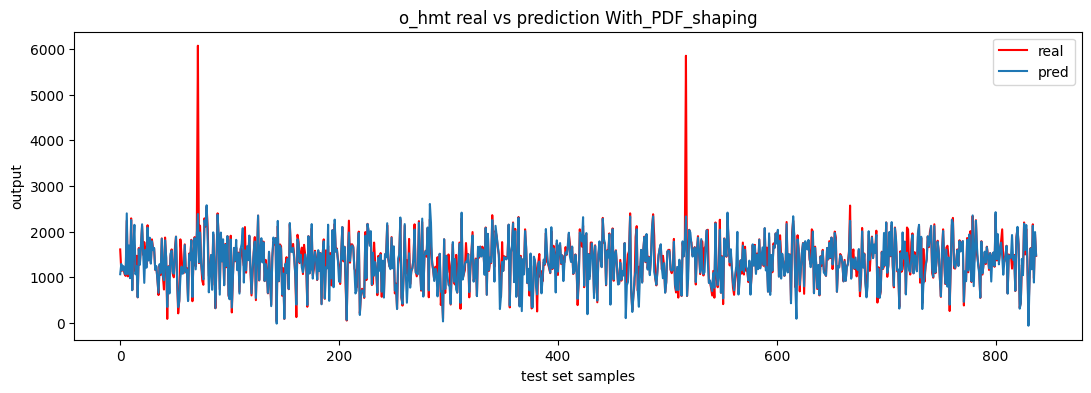

/Users/user/Desktop/CIVS_last_Phase/Forward/2025july/NewDataset/PDFshapingUtils.py:353: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error, bins=n_bins, color="blue")


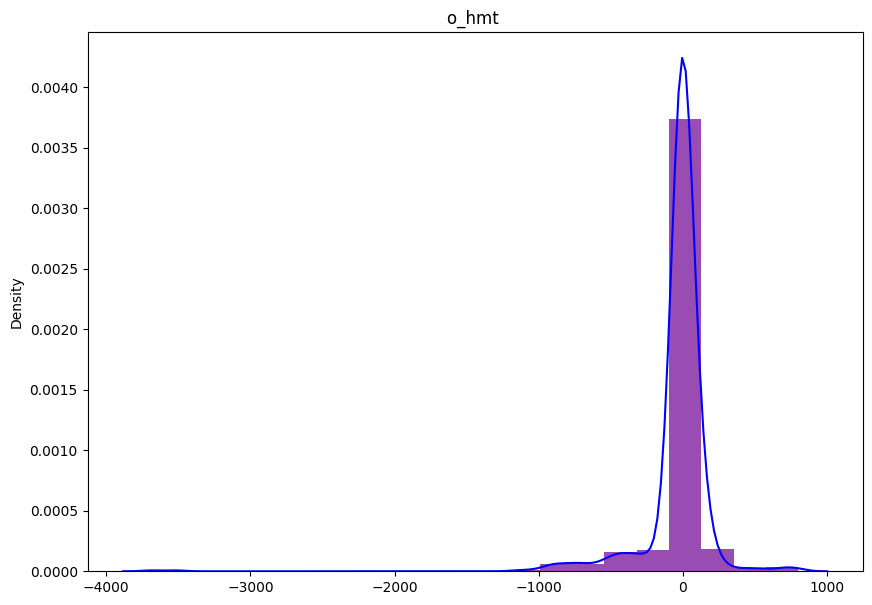

In [38]:

PDFshapingOBJ.plot_preds_vs_reals( list_preds, list_reals )



## To compare to NNs to XGBoost


In [39]:

##      y_pred = regressor.predict(PDFshapingOBJ.X_test )

pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)


In [40]:

## y_pred

pred_descaled


tensor([[1066.7649],
        [1292.4161],
        [1161.1853],
        [1247.4771],
        [1103.3038],
        [1050.4943],
        [2412.2896],
        [1083.9767],
        [ 990.0356],
        [ 983.6989],
        [2260.8706],
        [ 716.6844],
        [1635.9678],
        [1659.7400],
        [1084.0333],
        [1239.2255],
        [ 666.2131],
        [1615.1089],
        [1315.4814],
        [1678.9836],
        [2056.3115],
        [1513.4987],
        [ 894.3466],
        [1587.3054],
        [1386.3423],
        [2046.3721],
        [1399.5138],
        [1864.2247],
        [1278.4474],
        [1742.1946],
        [1612.2124],
        [1666.3418],
        [1163.7689],
        [1245.5160],
        [ 949.2063],
        [ 665.0803],
        [1264.1025],
        [1097.0349],
        [1844.9858],
        [1034.5428],
        [ 937.0259],
        [1832.8300],
        [1431.9591],
        [  75.1528],
        [1235.3728],
        [ 648.9901],
        [1514.2194],
        [1633

In [41]:

## r2_score( PDFshapingOBJ.y_test, y_pred )

print('Testing R**2 - scaled:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()    ))


Testing R**2 - scaled: 0.7028130027867
Testing R**2 - descaled: 0.7028129989553065



## Export ONNX model


In [42]:

'''

model.eval()

dummy_input = torch.randn(1, 6)


input_names = ["input1"]
output_names = ["output1", "output2"]

torch.onnx.export(
  model, 
  dummy_input, 
  "ONNXmodels/s894TuyereExitVeloMsPDFshapingRC.onnx", 
  verbose=False, 
  input_names  = input_names,
  output_names = output_names
)

'''


'\n\nmodel.eval()\n\ndummy_input = torch.randn(1, 6)\n\n\ninput_names = ["input1"]\noutput_names = ["output1", "output2"]\n\ntorch.onnx.export(\n  model, \n  dummy_input, \n  "ONNXmodels/s894TuyereExitVeloMsPDFshapingRC.onnx", \n  verbose=False, \n  input_names  = input_names,\n  output_names = output_names\n)\n\n'


## XGBoost


In [43]:

regressor = xgb.XGBRegressor(
    n_estimators=100,
    reg_lambda=1,
    gamma=0,
    max_depth=3
)


In [44]:

regressor.fit(PDFshapingOBJ.X_train, PDFshapingOBJ.y_train)


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=3, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0, reg_alpha=0,
             reg_lambda=1, ...)

In [45]:

print( len(PDFshapingOBJ.X_train  ))
print( len(PDFshapingOBJ.y_train  ))
  


3350
3350


In [46]:

## columns_thing = ['i_h2_inj_kg_thm', 'i_pul_coal_inj_kg_thm', 'i_nat_gas_inj_kg_thm', 'i_nat_gas_t_k', 
##                  'i_o2_vol_perce', 'i_hot_blast_temp_k', ]



## pd.DataFrame(regressor.feature_importances_.reshape(1, -1), columns=columns_thing)


In [47]:

y_pred = regressor.predict(PDFshapingOBJ.X_test )


In [48]:

y_pred


array([1228.0533 , 1223.6393 , 1034.8622 , 1247.1276 , 1157.7773 ,
       1103.1461 , 2435.8516 ,  999.9153 , 1551.1084 ,  969.2468 ,
       2204.9456 ,  757.906  , 1696.2489 , 1699.9756 , 1051.6434 ,
       1516.9067 ,  700.49567, 1706.5231 , 1193.9998 , 1754.7814 ,
       2111.5464 , 1504.9181 , 1701.861  , 1521.4539 , 1170.2378 ,
       2078.7913 , 1469.2114 , 1757.4604 , 1356.0037 , 1760.678  ,
       1590.667  , 1640.837  , 1132.9773 , 1351.5735 ,  946.8886 ,
        597.72394, 1250.3253 , 1179.3169 , 1842.3795 , 1029.1118 ,
        816.28894, 1899.371  , 1454.7993 ,   75.4096 , 1260.0676 ,
        920.1964 , 1499.1124 , 1706.5231 , 1148.4341 , 1071.5732 ,
       1613.2109 , 1898.4719 ,  932.90295,  201.1794 ,  607.29364,
       1723.0679 , 1378.3127 , 1179.8628 , 1202.6243 , 1695.9655 ,
       1109.3569 , 1227.588  ,  569.99005, 1592.4095 , 1451.151  ,
       1812.7175 ,  541.39575, 1480.9409 , 1879.7316 , 1124.3107 ,
       1981.4426 , 3226.3115 , 1286.2535 , 2035.2653 , 1200.69

In [49]:

mean_squared_error(PDFshapingOBJ.y_test , y_pred)


26608.484

In [50]:

r2_score( PDFshapingOBJ.y_test, y_pred )


0.9065835539484635

In [51]:

len(y_pred) 


838

In [52]:

list_preds = []
list_reals = []

print( "preds, real"   )
  
for j in range(   len(y_pred)    ):
    print(   y_pred[j], PDFshapingOBJ.y_test[j][0]   )
    
    list_preds.append(   y_pred[j]   )
    list_reals.append(  PDFshapingOBJ.y_test[j][0]   )


preds, real
1228.0533 1610.0
1223.6393 1140.0
1034.8622 1150.0
1247.1276 1190.0
1157.7773 1070.0
1103.1461 1030.0
2435.8516 2240.0
999.9153 1020.0
1551.1084 1530.0
969.2468 981.0
2204.9456 2290.0
757.906 722.0
1696.2489 1690.0
1699.9756 1700.0
1051.6434 1120.0
1516.9067 1470.0
700.49567 561.0
1706.5231 1640.0
1193.9998 1310.0
1754.7814 1730.0
2111.5464 2120.0
1504.9181 1490.0
1701.861 1770.0
1521.4539 1600.0
1170.2378 1270.0
2078.7913 2140.0
1469.2114 1560.0
1757.4604 1780.0
1356.0037 1310.0
1760.678 1830.0
1590.667 1640.0
1640.837 1630.0
1132.9773 1160.0
1351.5735 1220.0
946.8886 970.0
597.72394 611.0
1250.3253 1260.0
1179.3169 1050.0
1842.3795 1850.0
1029.1118 1030.0
816.28894 732.0
1899.371 1870.0
1454.7993 1420.0
75.4096 89.1
1260.0676 1240.0
920.1964 1080.0
1499.1124 1470.0
1706.5231 1610.0
1148.4341 1080.0
1071.5732 1000.0
1613.2109 1630.0
1898.4719 1890.0
932.90295 924.0
201.1794 210.0
607.29364 498.0
1723.0679 1830.0
1378.3127 1490.0
1179.8628 1100.0
1202.6243 1090.0
1695.9655 

In [53]:

len( list_preds )


838

In [54]:

len( list_reals )


838

In [55]:

PDFshapingOBJ.the_string           = "XGBoost"
PDFshapingOBJ.furnace_model_name   = "o_prod_rt"


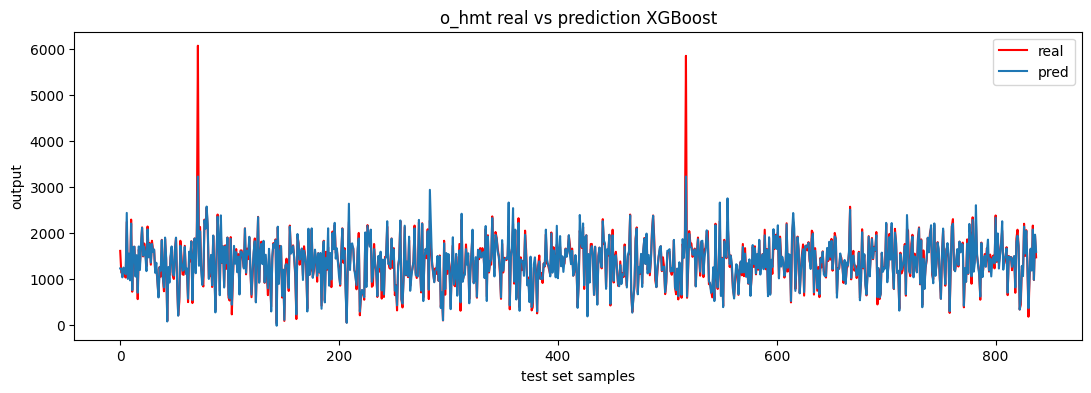

/Users/user/Desktop/CIVS_last_Phase/Forward/2025july/NewDataset/PDFshapingUtils.py:353: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error, bins=n_bins, color="blue")


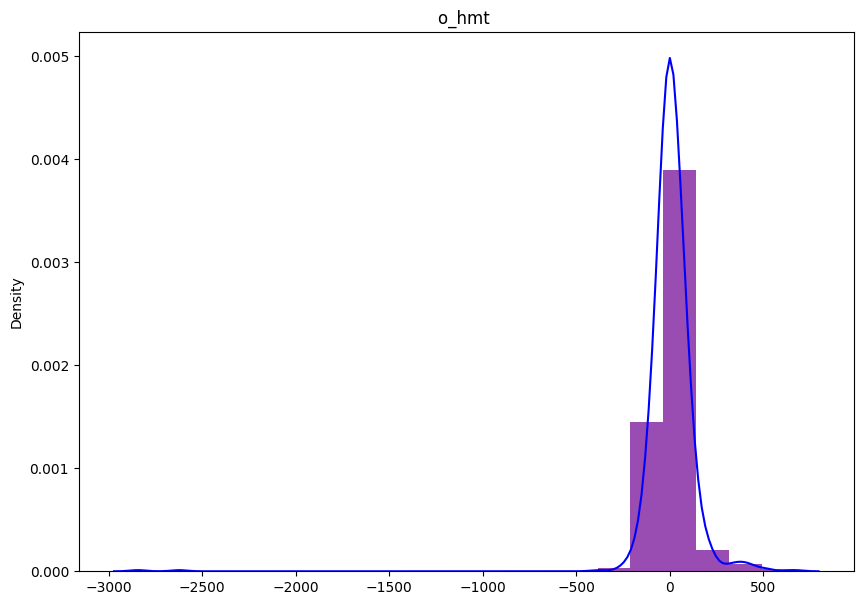

In [56]:

PDFshapingOBJ.plot_preds_vs_reals( list_preds, list_reals )



## ONNX and XGboost


In [57]:

model = xgb.XGBRegressor(
    n_estimators=100,
    reg_lambda=1,
    gamma=0,
    max_depth=3
)


In [58]:


print(model)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, gamma=0, gpu_id=None,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, predictor=None, random_state=None,
             reg_alpha=None, reg_lambda=1, ...)


In [59]:

model.fit( PDFshapingOBJ.X_train, PDFshapingOBJ.y_train)


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=3, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0, reg_alpha=0,
             reg_lambda=1, ...)

In [60]:

y_pred = model.predict(PDFshapingOBJ.X_test )


In [61]:

y_pred


array([1228.0533 , 1223.6393 , 1034.8622 , 1247.1276 , 1157.7773 ,
       1103.1461 , 2435.8516 ,  999.9153 , 1551.1084 ,  969.2468 ,
       2204.9456 ,  757.906  , 1696.2489 , 1699.9756 , 1051.6434 ,
       1516.9067 ,  700.49567, 1706.5231 , 1193.9998 , 1754.7814 ,
       2111.5464 , 1504.9181 , 1701.861  , 1521.4539 , 1170.2378 ,
       2078.7913 , 1469.2114 , 1757.4604 , 1356.0037 , 1760.678  ,
       1590.667  , 1640.837  , 1132.9773 , 1351.5735 ,  946.8886 ,
        597.72394, 1250.3253 , 1179.3169 , 1842.3795 , 1029.1118 ,
        816.28894, 1899.371  , 1454.7993 ,   75.4096 , 1260.0676 ,
        920.1964 , 1499.1124 , 1706.5231 , 1148.4341 , 1071.5732 ,
       1613.2109 , 1898.4719 ,  932.90295,  201.1794 ,  607.29364,
       1723.0679 , 1378.3127 , 1179.8628 , 1202.6243 , 1695.9655 ,
       1109.3569 , 1227.588  ,  569.99005, 1592.4095 , 1451.151  ,
       1812.7175 ,  541.39575, 1480.9409 , 1879.7316 , 1124.3107 ,
       1981.4426 , 3226.3115 , 1286.2535 , 2035.2653 , 1200.69

In [62]:

r2_score( PDFshapingOBJ.y_test, y_pred )


0.9065835539484635

In [63]:

initial_types = [(
         'float_input', 
         FloatTensorType(     [ None, PDFshapingOBJ.X.shape[1] ]       )
)]


In [64]:

## target_opset=7

onnx_model = onnxmltools.convert_xgboost(model, initial_types=initial_types)

onnxmltools.utils.save_model(onnx_model, 'ONNXmodels/xgboost_o_prod_rt_ort.onnx')


In [65]:

# Setup runtime. This instantiates an ONNX inference session and loads the persisted model.
sess = rt.InferenceSession("ONNXmodels/xgboost_o_prod_rt_ort.onnx")


In [66]:

# Get model metadata to enable mapping of new input to the runtime model
input_name = sess.get_inputs()[0].name
label_name = sess.get_outputs()[0].name


In [67]:

input_name 


'float_input'

In [68]:

label_name


'variable'

In [69]:

# Create predictions. The inputs are the xtest values, and they are being casted as type float32.
pred_onnx = sess.run([label_name], {input_name: PDFshapingOBJ.X_test.astype(np.float32)})[0]


In [70]:

# Print first 10 predictions
print("Prediction:\n", pred_onnx[0:10])


Prediction:
 [[1228.0531 ]
 [1223.639  ]
 [1034.8619 ]
 [1247.1273 ]
 [1157.7771 ]
 [1103.1458 ]
 [2435.8508 ]
 [ 999.91516]
 [1551.1079 ]
 [ 969.24677]]


In [71]:

test_count = 10
test_cases = PDFshapingOBJ.X_test[0:test_count]
local_pred = model.predict(test_cases)
print(f"Local predictions are: {local_pred}")


Local predictions are: [1228.0533 1223.6393 1034.8622 1247.1276 1157.7773 1103.1461 2435.8516
  999.9153 1551.1084  969.2468]


In [72]:

test_cases


array([[  20. ,    0. ,    0. ,   70. ,   27. ,  300. ,  300. , 1480. ,
         195. ,    5.7,    7. ,    0. ,    0. ,    0. ],
       [  20. ,    0. ,    0. ,   90. ,   30. ,  300. ,  300. , 1600. ,
         195. ,    5.7,    7. ,    0. ,    0. ,    0. ],
       [  10. ,    0. ,    0. ,  100. ,   30. ,  300. ,  300. , 1200. ,
         230. ,    5.7,    7. ,    0. ,    0. ,    0. ],
       [  10. ,    0. ,    0. ,   60. ,   24. ,  300. ,  300. , 1600. ,
         195. ,    5.7,    5. ,    0. ,    0. ,    0. ],
       [  20. ,    0. ,    0. ,    0. ,   24. ,    0. , 1200. , 1200. ,
         195. ,    5.7,    3. ,    0. ,    0. ,    0. ],
       [   0. ,    0. ,    0. ,   41. ,   21. ,  700. ,    0. , 1200. ,
         230. ,    5.7,    3. ,    0. ,    0. ,    0. ],
       [   0. ,    0. ,    0. ,   41. ,   27. ,  300. ,    0. , 1600. ,
         230. ,    5.7,    7. ,    0. ,    0. ,    0. ],
       [   0. ,   20. ,    0. ,   80. ,   21. ,  300. ,    0. , 1480. ,
         230. ,    5.7,  


## ONNX, XGBoost, and SKlearn pipeline


In [73]:

update_registered_converter(
    XGBRegressor, 'XGBoostXGBRegressor',
    calculate_linear_regressor_output_shapes, 
    convert_xgboost
)


In [74]:

model = xgb.XGBRegressor(
    n_estimators=100,
    reg_lambda=1,
    gamma=0,
    max_depth=3
)

pipe = Pipeline([
            ('xgb', model) 
])



pipe.fit( PDFshapingOBJ.X_train, PDFshapingOBJ.y_train)


Pipeline(steps=[('xgb',
                 XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
                              colsample_bylevel=1, colsample_bynode=1,
                              colsample_bytree=1, early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              gamma=0, gpu_id=-1, grow_policy='depthwise',
                              importance_type=None, interaction_constraints='',
                              learning_rate=0.300000012, max_bin=256,
                              max_cat_to_onehot=4, max_delta_step=0,
                              max_depth=3, max_leaves=0, min_child_weight=1,
                              missing=nan, monotone_constraints='()',
                              n_estimators=100, n_jobs=0, num_parallel_tree=1,
                              predictor='auto', random_state=0, reg_alpha=0,
                              reg_lambda=1, ...))])

In [75]:

y_pred = pipe.predict(PDFshapingOBJ.X_test )


In [76]:

y_pred


array([1228.0533 , 1223.6393 , 1034.8622 , 1247.1276 , 1157.7773 ,
       1103.1461 , 2435.8516 ,  999.9153 , 1551.1084 ,  969.2468 ,
       2204.9456 ,  757.906  , 1696.2489 , 1699.9756 , 1051.6434 ,
       1516.9067 ,  700.49567, 1706.5231 , 1193.9998 , 1754.7814 ,
       2111.5464 , 1504.9181 , 1701.861  , 1521.4539 , 1170.2378 ,
       2078.7913 , 1469.2114 , 1757.4604 , 1356.0037 , 1760.678  ,
       1590.667  , 1640.837  , 1132.9773 , 1351.5735 ,  946.8886 ,
        597.72394, 1250.3253 , 1179.3169 , 1842.3795 , 1029.1118 ,
        816.28894, 1899.371  , 1454.7993 ,   75.4096 , 1260.0676 ,
        920.1964 , 1499.1124 , 1706.5231 , 1148.4341 , 1071.5732 ,
       1613.2109 , 1898.4719 ,  932.90295,  201.1794 ,  607.29364,
       1723.0679 , 1378.3127 , 1179.8628 , 1202.6243 , 1695.9655 ,
       1109.3569 , 1227.588  ,  569.99005, 1592.4095 , 1451.151  ,
       1812.7175 ,  541.39575, 1480.9409 , 1879.7316 , 1124.3107 ,
       1981.4426 , 3226.3115 , 1286.2535 , 2035.2653 , 1200.69

In [77]:

r2_score( PDFshapingOBJ.y_test, y_pred )


0.9065835539484635

In [78]:

model_onnx = convert_sklearn(
    pipe, 
    'pipeline_xgboost_o_prod_rt',
    [ ('input', FloatTensorType([None, PDFshapingOBJ.X.shape[1]])) ],
    target_opset={'': 7, 'ai.onnx.ml': 1})


In [79]:

with open("ONNXmodels/pipeline_xgboost_o_prod_rt.onnx", "wb") as f:
    f.write(model_onnx.SerializeToString())
    

In [80]:
onx = to_onnx(pipe, PDFshapingOBJ.X_test.astype(np.float32),
              target_opset={'': 7, 'ai.onnx.ml': 1})

sess = rt.InferenceSession(onx.SerializeToString())
pred_onx = sess.run(None, {"X": PDFshapingOBJ.X_test[:5].astype(np.float32)})
print("predict", pred_onx[0].ravel())



predict [1228.0533 1223.6393 1034.8622 1247.1276 1157.7773]


In [81]:

input_name = sess.get_inputs()[0].name
label_name = sess.get_outputs()[0].name


In [82]:
label_name 

'variable'

In [83]:
input_name 

'X'